# 1 - Exploratory Data Analysis

All visuals in this notebook are produced directly by notebook cells. No figure files are opened during presentation.

In [ ]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
DATA_PATH = Path('../data/raw/Metro_Interstate_Traffic_Volume.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['date_time']).sort_values('date_time').reset_index(drop=True)
clean_df = df[df['temp'] != 0].copy()
clean_df['hour'] = clean_df['date_time'].dt.hour
clean_df['day_of_week'] = clean_df['date_time'].dt.dayofweek
clean_df['month'] = clean_df['date_time'].dt.month
clean_df['year'] = clean_df['date_time'].dt.year
clean_df['date'] = clean_df['date_time'].dt.date
clean_df['temp_c'] = clean_df['temp'] - 273.15
clean_df['traffic_level'] = pd.qcut(clean_df['traffic_volume'], q=3, labels=['Low', 'Moderate', 'High'])
df.head()

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main weather_description           date_time  traffic_volume
0     NaN  288.28      0.0      0.0          40       Clouds    scattered clouds 2012-10-02 09:00:00            5545
1     NaN  289.36      0.0      0.0          75       Clouds       broken clouds 2012-10-02 10:00:00            4516
2     NaN  289.58      0.0      0.0          90       Clouds     overcast clouds 2012-10-02 11:00:00            4767
3     NaN  290.13      0.0      0.0          90       Clouds     overcast clouds 2012-10-02 12:00:00            5026
4     NaN  291.14      0.0      0.0          75       Clouds       broken clouds 2012-10-02 13:00:00            4918


## Dataset Overview

Basic shape, date range, and invalid temperature removal.

In [ ]:
overview

                                      value
raw_rows                              48204
columns                                   9
start_date              2012-10-02 09:00:00
end_date                2018-09-30 23:00:00
temp_zero_rows_removed                   10
rows_after_cleaning                   48194


In [ ]:
summary

       traffic_volume      temp   rain_1h   snow_1h  clouds_all
count        48194.00  48194.00  48194.00  48194.00    48194.00
mean          3260.22    281.26      0.33      0.00       49.37
std           1986.76     12.71     44.79      0.01       39.01
min              0.00    243.39      0.00      0.00        0.00
25%           1194.00    272.18      0.00      0.00        1.00
50%           3380.50    282.46      0.00      0.00       64.00
75%           4933.00    291.81      0.00      0.00       90.00
max           7280.00    310.07   9831.30      0.51      100.00


## Missingness Pattern Visualization

In [ ]:
df.isna().sum()

                     missing_count
holiday                      48143
temp                             0
rain_1h                          0
snow_1h                          0
clouds_all                       0
weather_main                     0
weather_description              0
date_time                        0
traffic_volume                   0


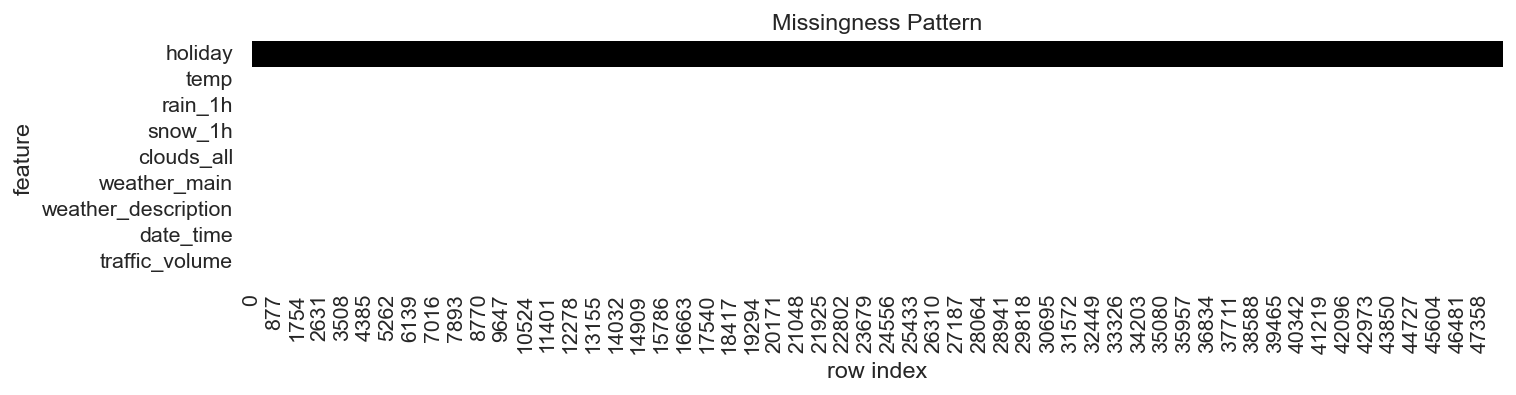

In [ ]:
missing_matrix = df.isna().astype(int)
plt.figure(figsize=(11, 3))
sns.heatmap(missing_matrix.T, cbar=False, cmap='Greys')
plt.title('Missingness Pattern')
plt.xlabel('row index')
plt.ylabel('feature')
plt.show()

## Univariate Analysis

Histograms, KDE curves, skewness, and kurtosis.

In [ ]:
skew_kurtosis

                skewness   kurtosis
traffic_volume    -0.090     -1.309
temp_c            -0.364     -0.659
rain_1h          219.366  48145.637
snow_1h           48.362   2619.921
clouds_all        -0.198     -1.742


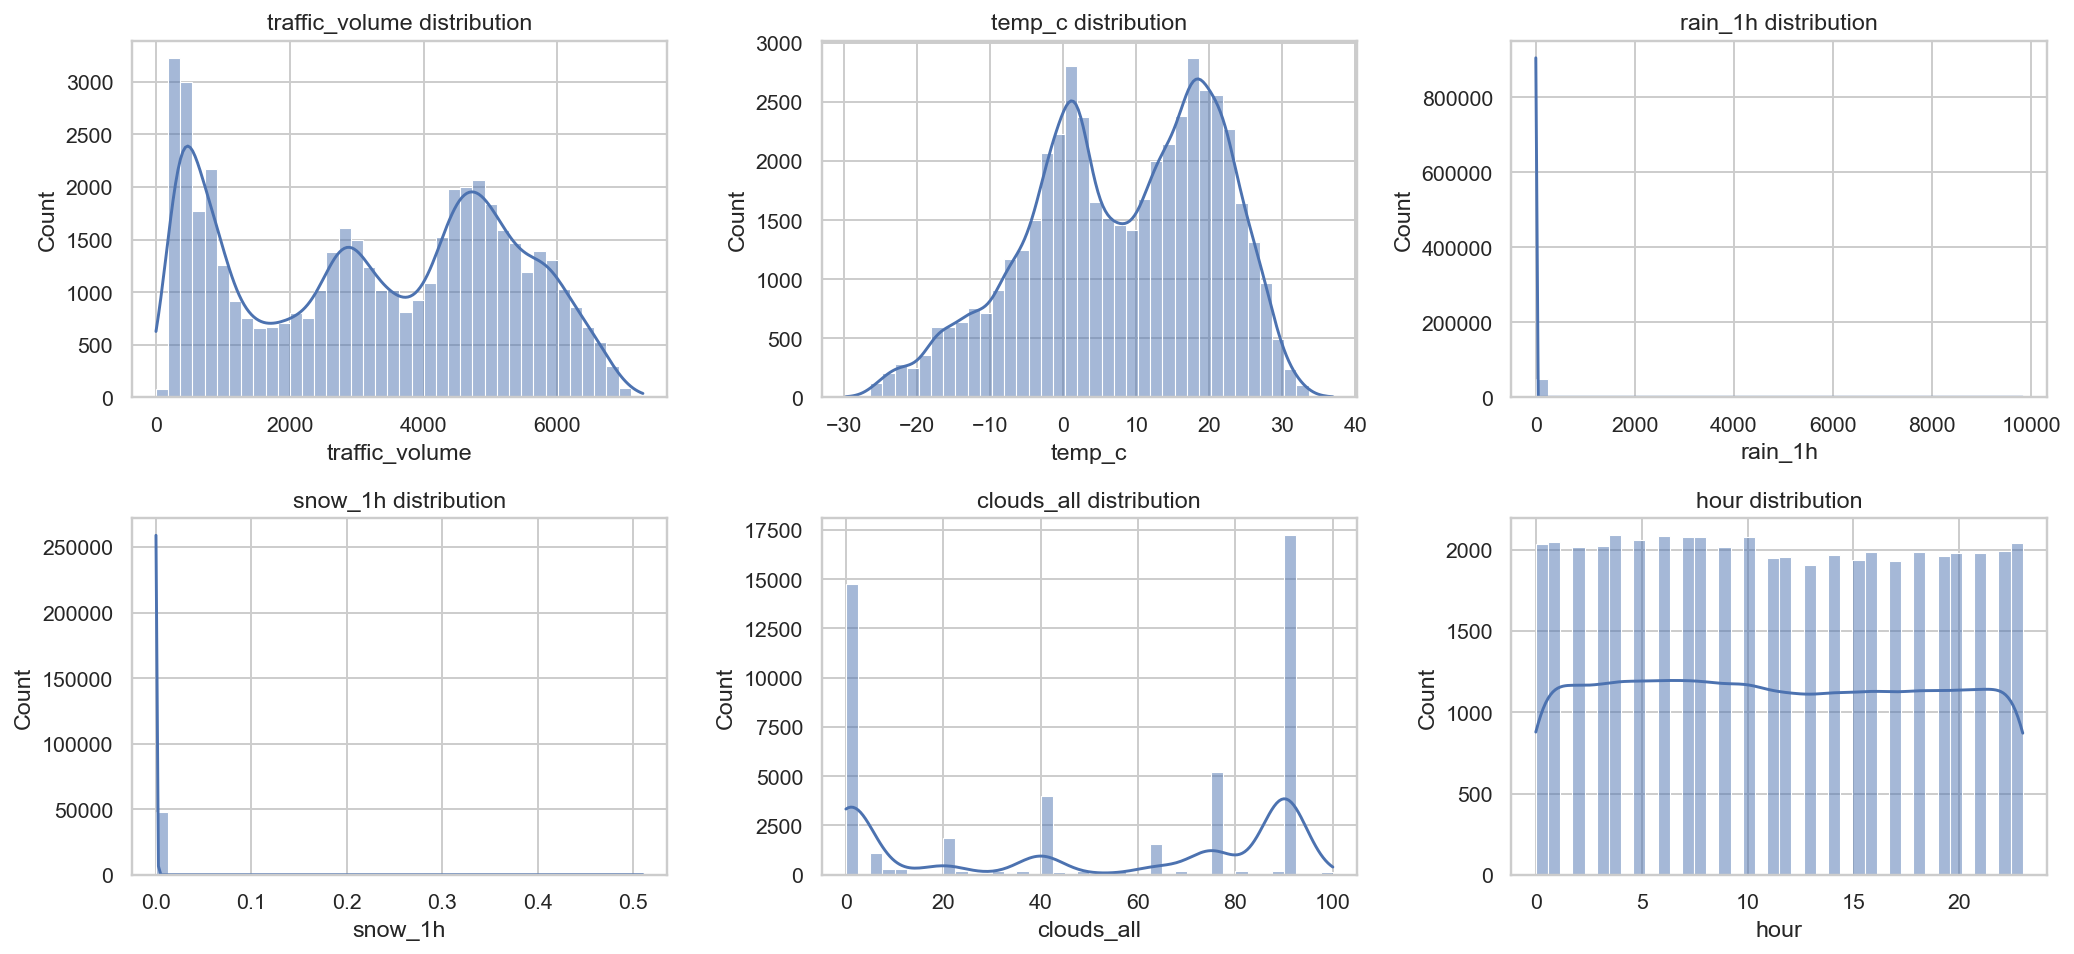

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), ['traffic_volume', 'temp_c', 'rain_1h', 'snow_1h', 'clouds_all', 'hour']):
    sns.histplot(clean_df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'{col} distribution')
plt.show()

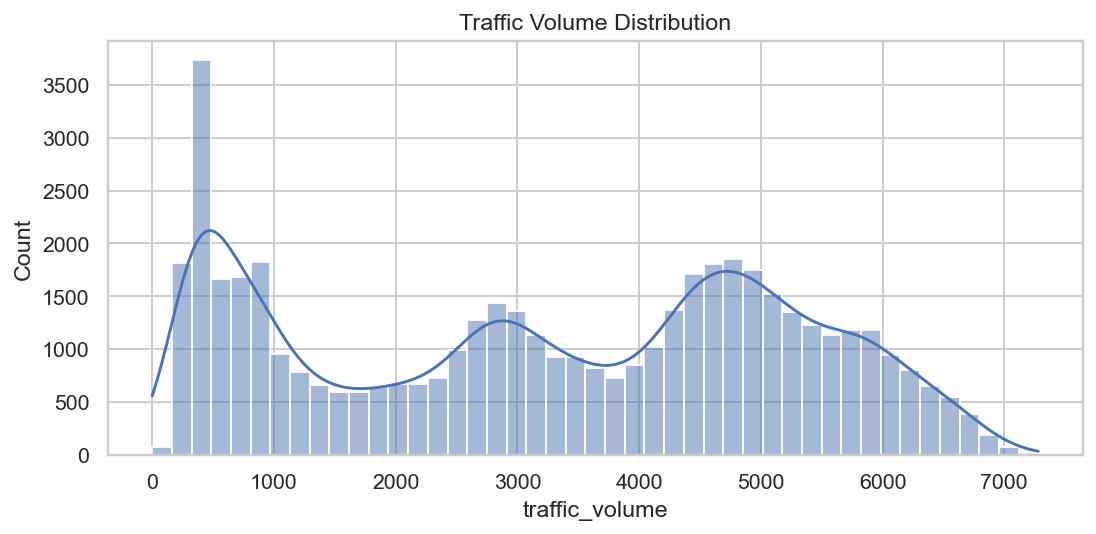

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(clean_df['traffic_volume'], bins=45, kde=True)
plt.title('Traffic Volume Distribution')
plt.show()

## Bivariate Analysis

Correlation matrix and outlier inspection.

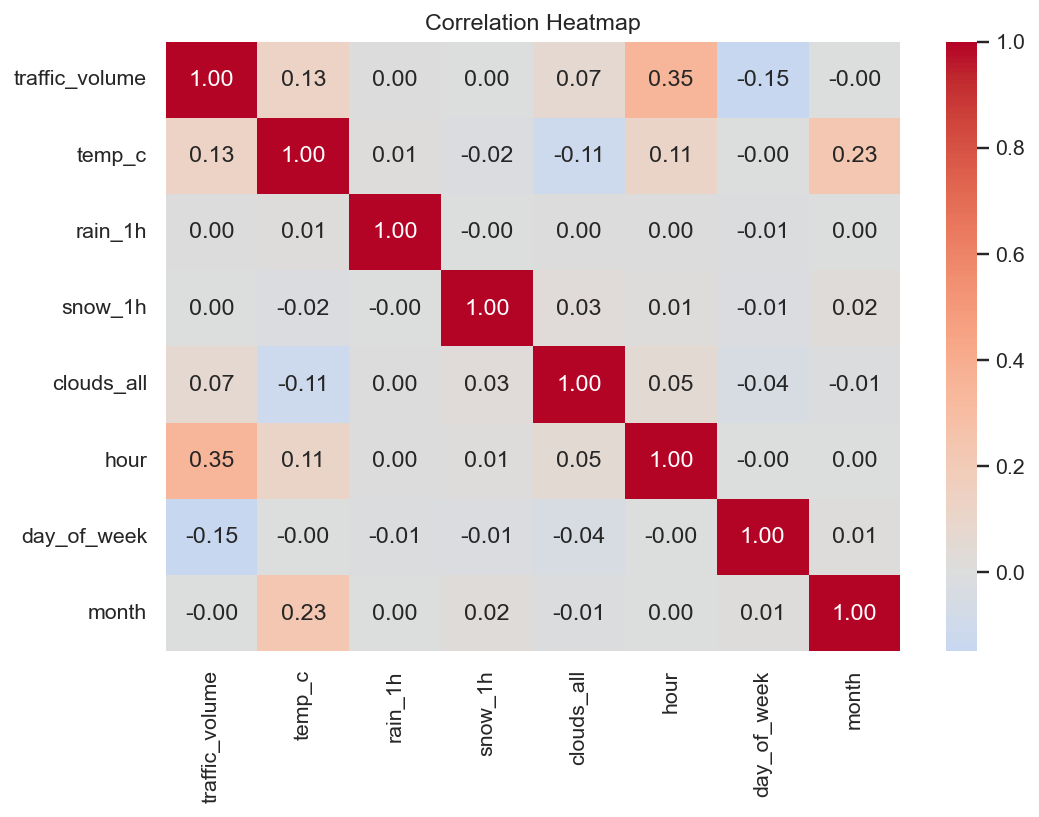

In [ ]:
corr_cols = ['traffic_volume', 'temp_c', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month']
plt.figure(figsize=(8, 6))
sns.heatmap(clean_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

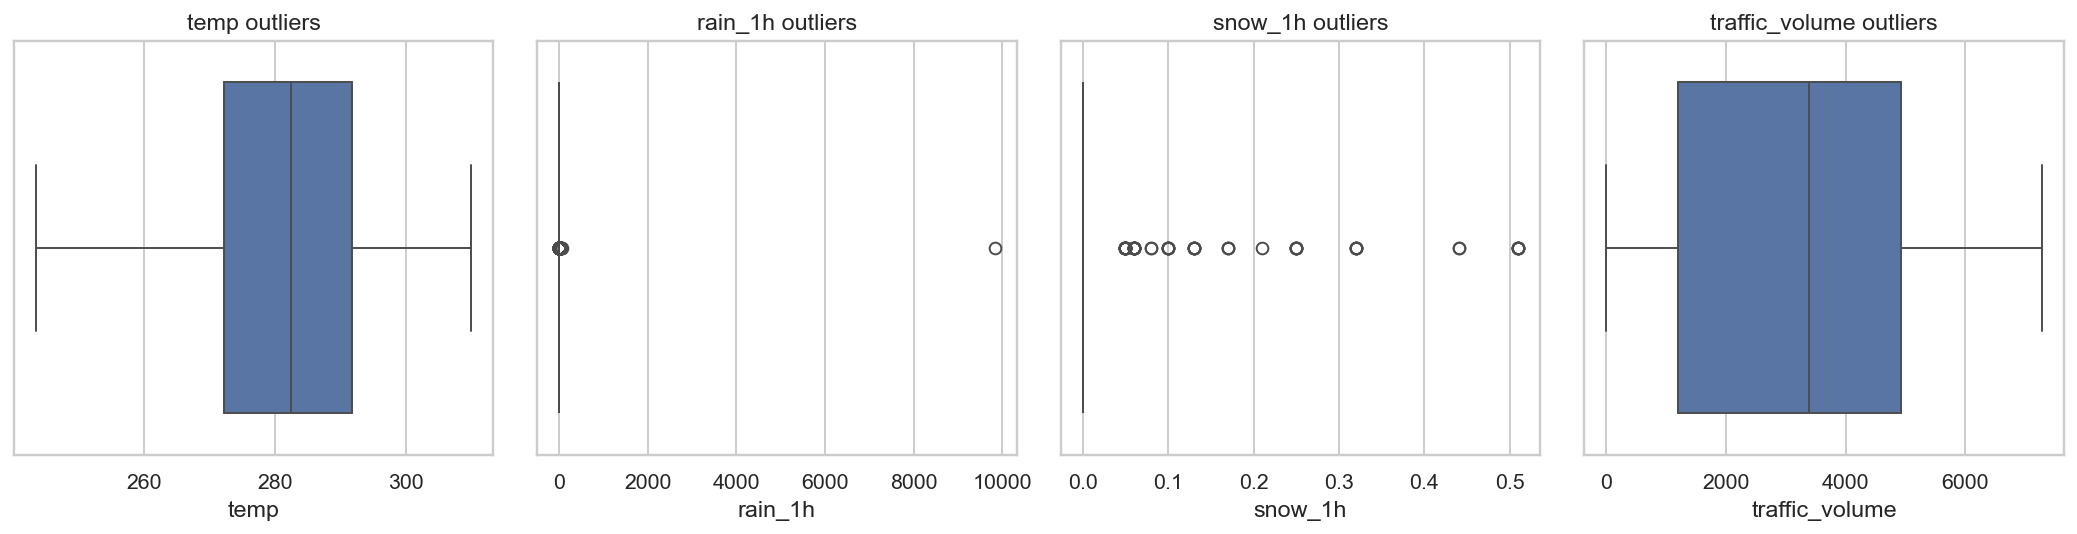

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, ['temp', 'rain_1h', 'snow_1h', 'traffic_volume']):
    sns.boxplot(x=clean_df[col], ax=ax)
    ax.set_title(f'{col} outliers')
plt.show()

## Combining / Splitting Features

`date_time` is split into `hour`, `day_of_week`, `month`, and `year`.

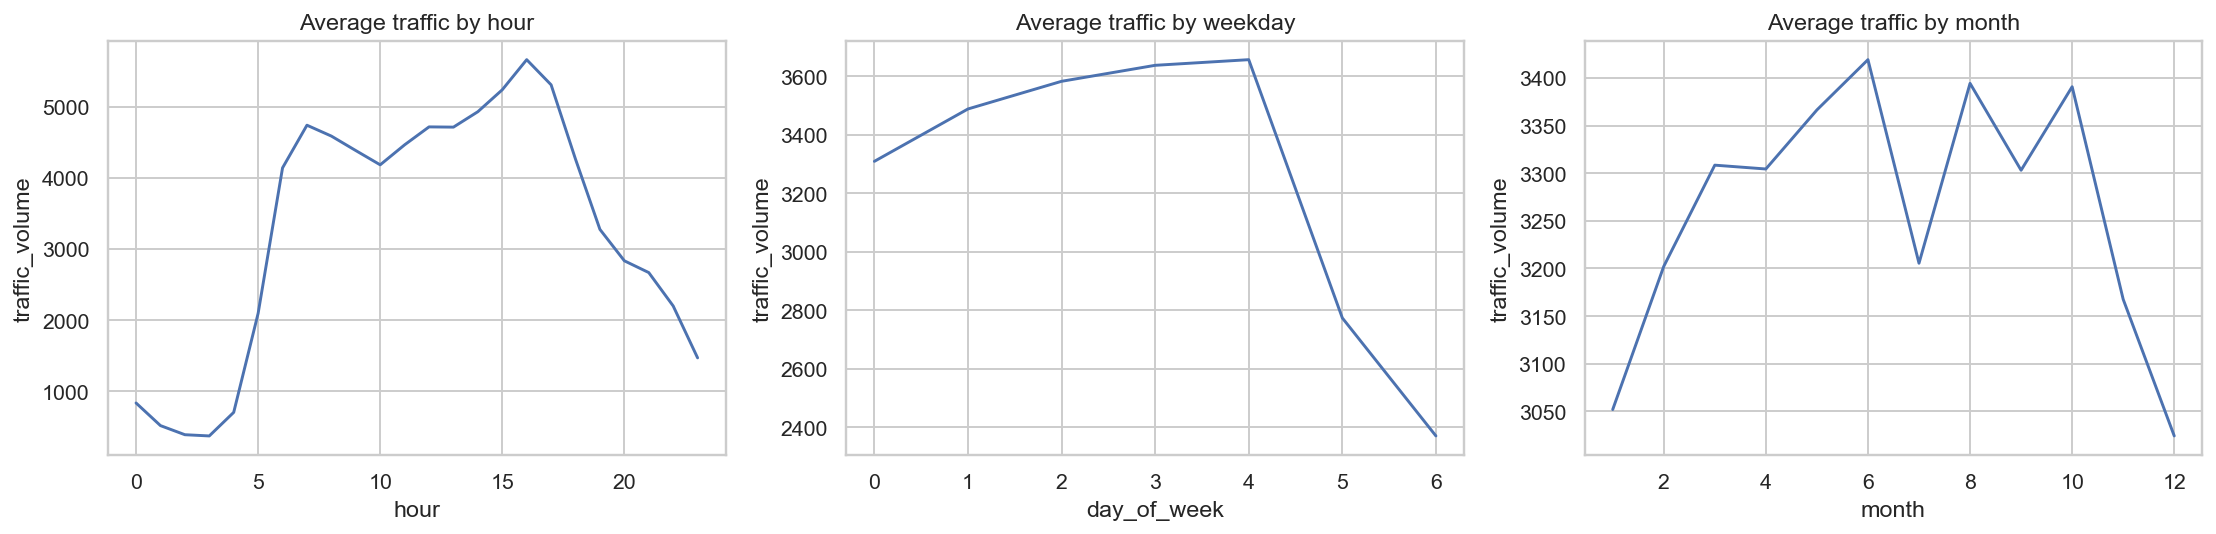

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.lineplot(data=clean_df, x='hour', y='traffic_volume', estimator='mean', errorbar=None, ax=axes[0])
sns.lineplot(data=clean_df, x='day_of_week', y='traffic_volume', estimator='mean', errorbar=None, ax=axes[1])
sns.lineplot(data=clean_df, x='month', y='traffic_volume', estimator='mean', errorbar=None, ax=axes[2])
plt.show()

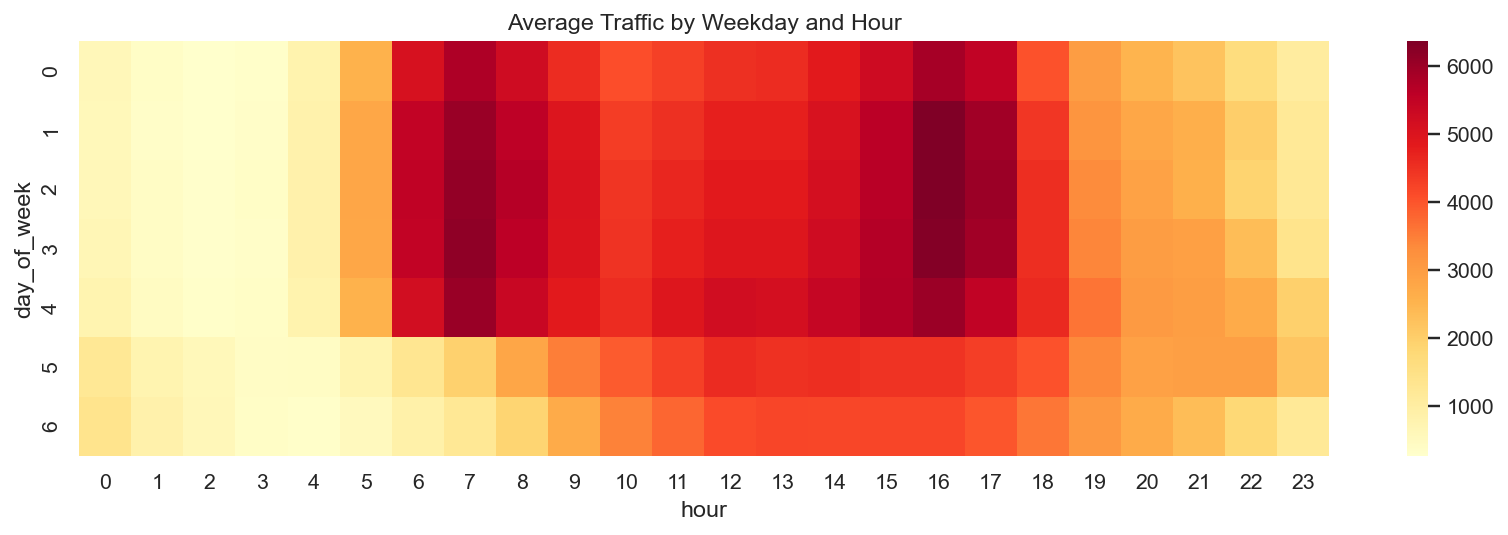

In [ ]:
pivot = clean_df.pivot_table(values='traffic_volume', index='day_of_week', columns='hour', aggfunc='mean')
plt.figure(figsize=(12, 4))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Average Traffic by Weekday and Hour')
plt.show()

## Weather Visualizations

Weather category counts and target-conditional weather behavior.

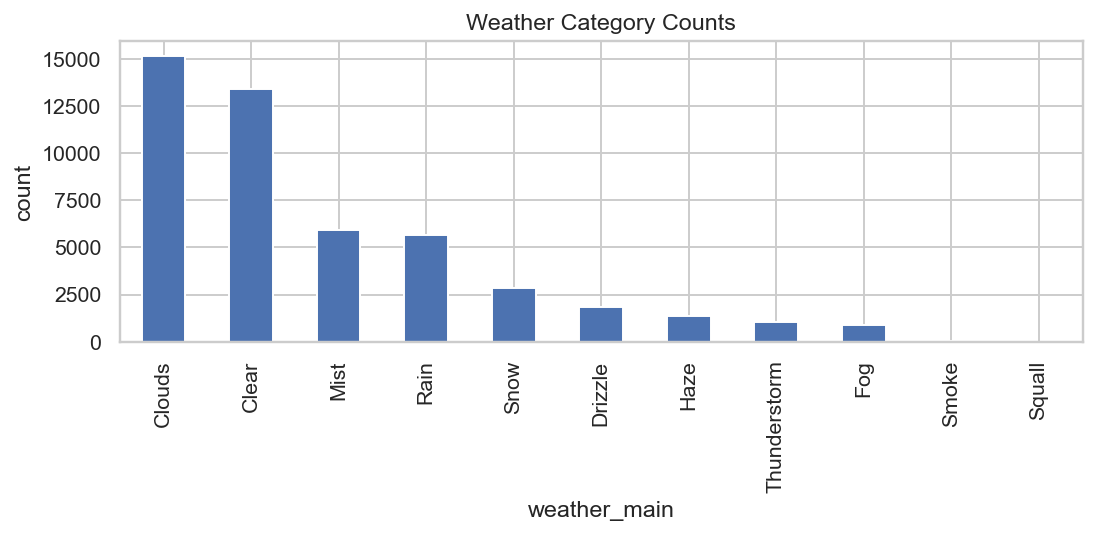

In [ ]:
plt.figure(figsize=(8, 4))
clean_df['weather_main'].value_counts().plot(kind='bar')
plt.title('Weather Category Counts')
plt.ylabel('count')
plt.show()

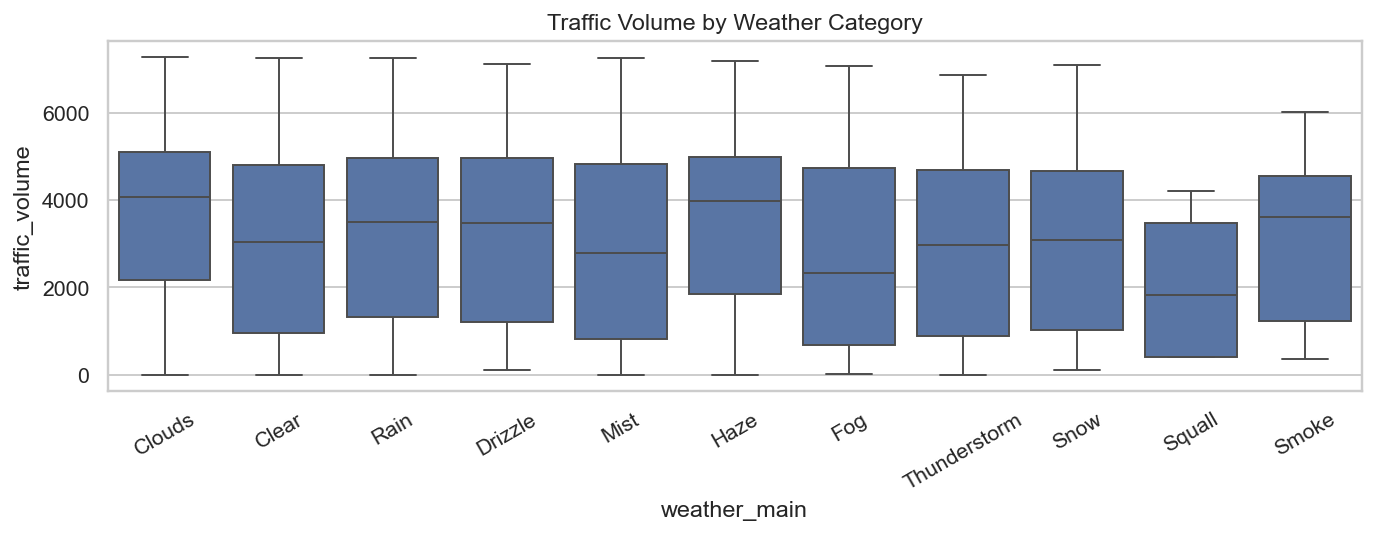

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=clean_df, x='weather_main', y='traffic_volume')
plt.xticks(rotation=30)
plt.title('Traffic Volume by Weather Category')
plt.show()

## Multivariate Analysis

Pair plot, parallel coordinates, PCA, and t-SNE show structure across multiple variables.

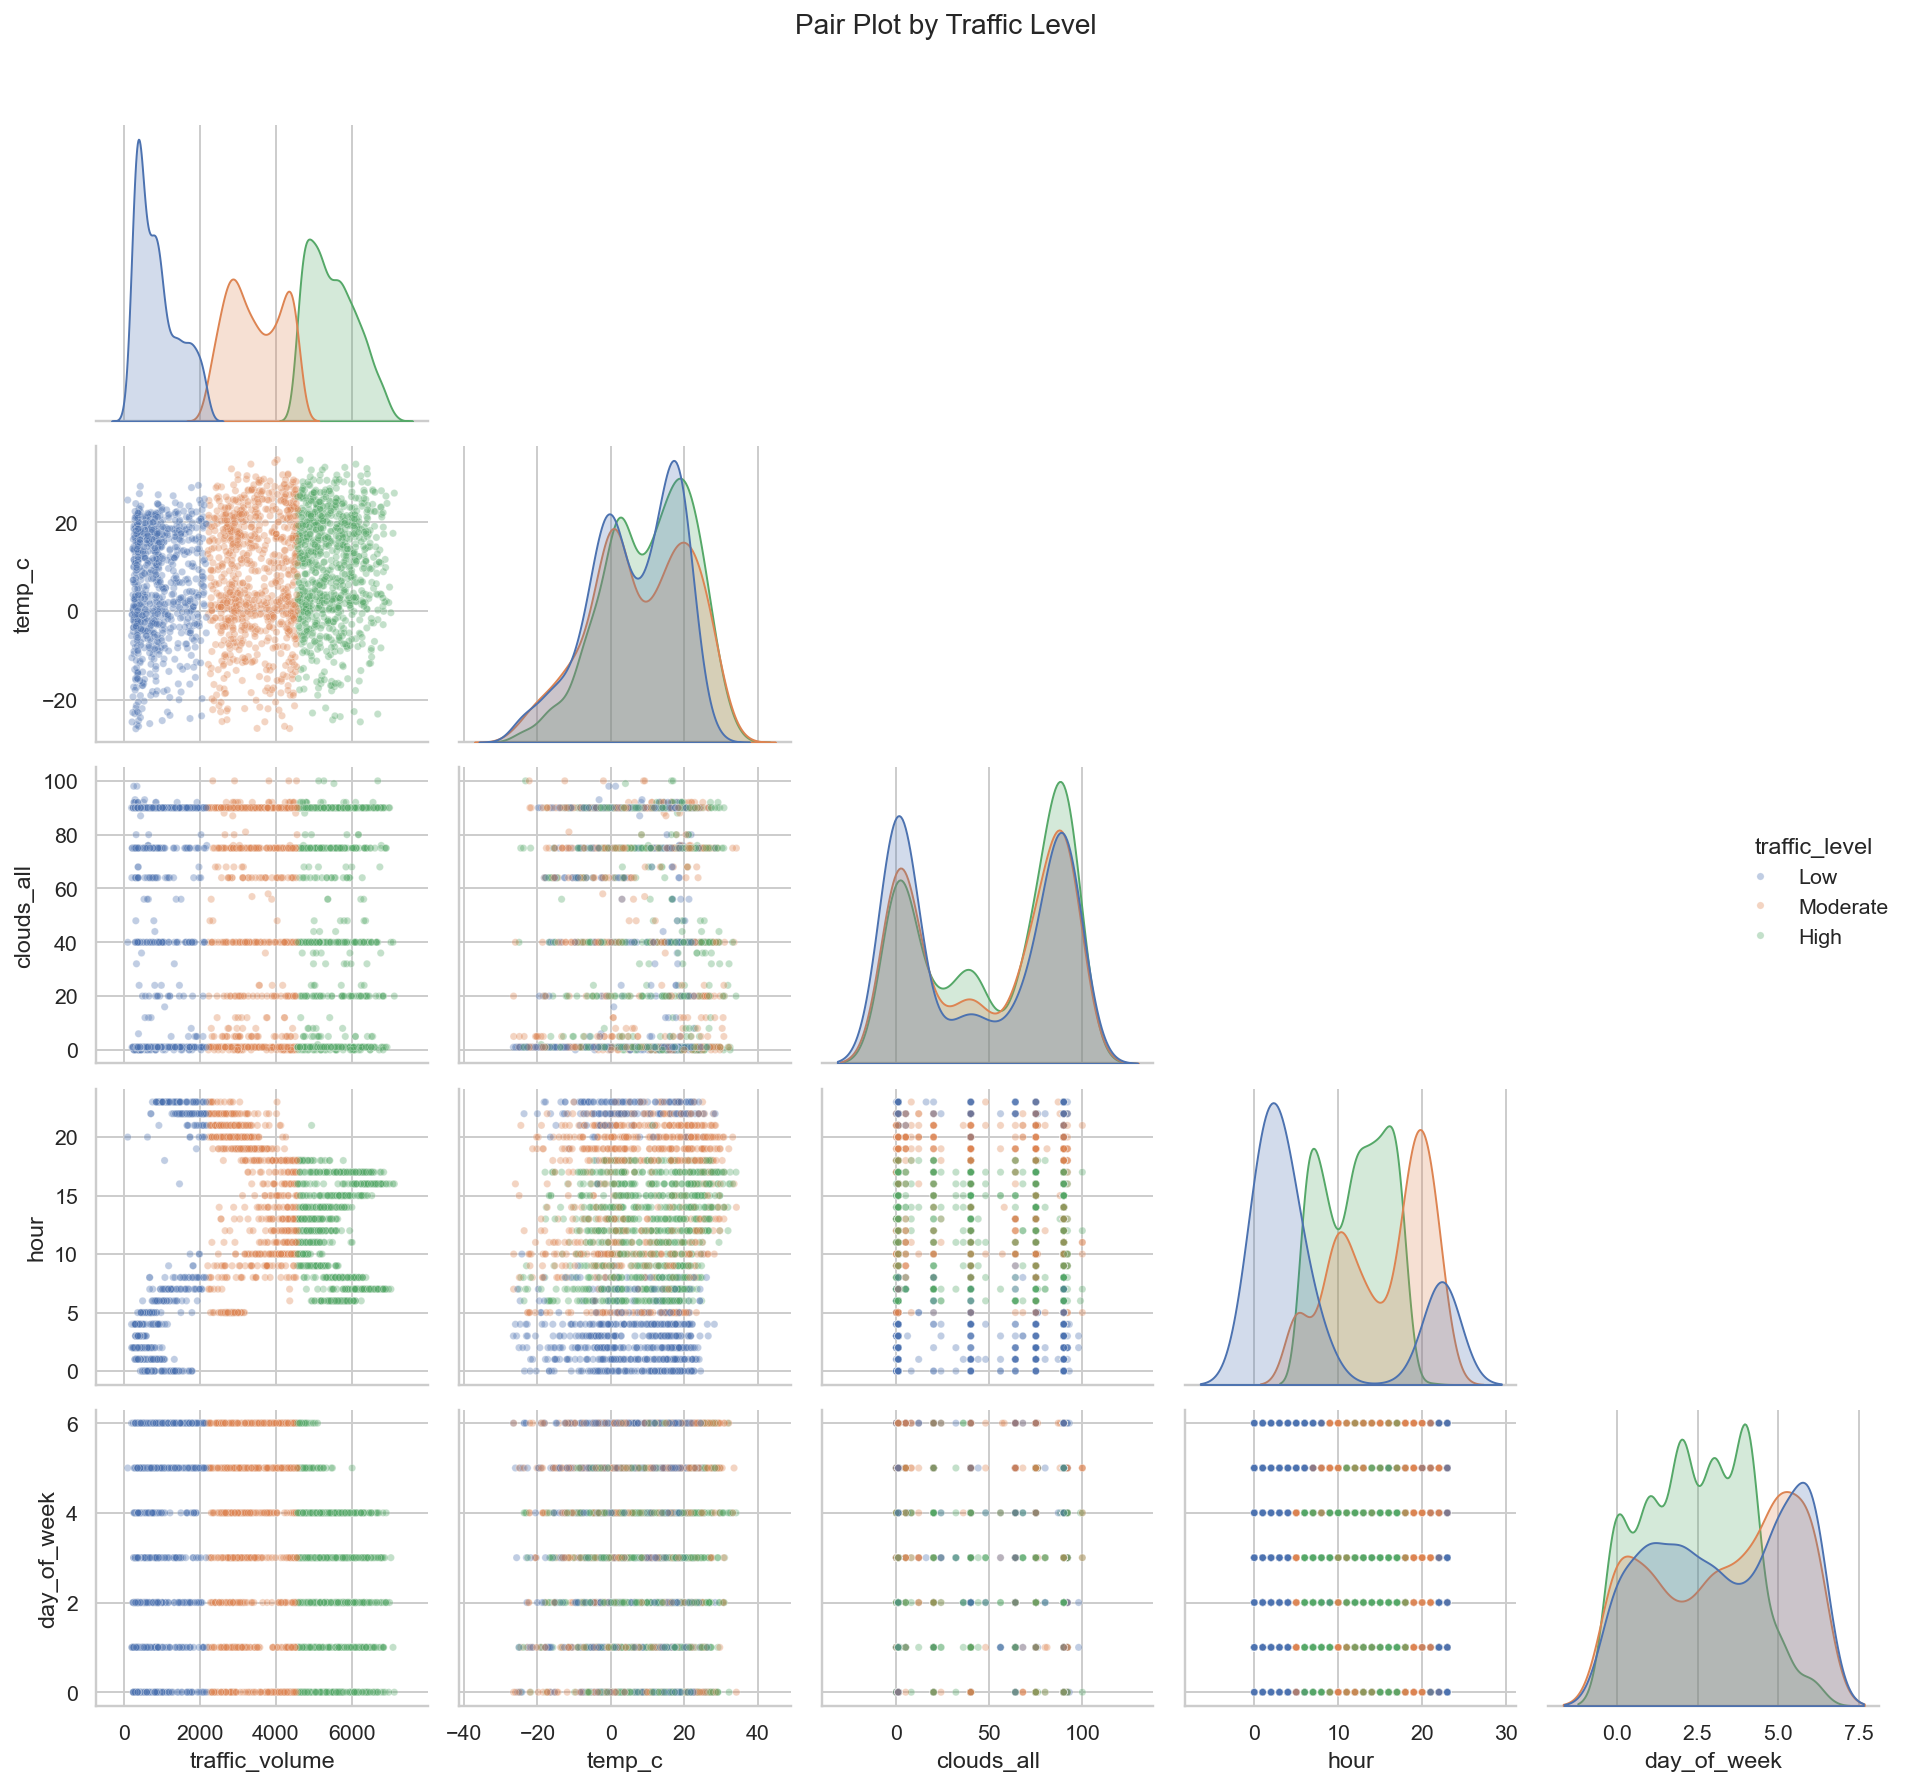

In [ ]:
sample = clean_df.sample(min(2500, len(clean_df)), random_state=42)
sns.pairplot(sample[['traffic_volume', 'temp_c', 'clouds_all', 'hour', 'day_of_week', 'traffic_level']], hue='traffic_level', corner=True)
plt.show()

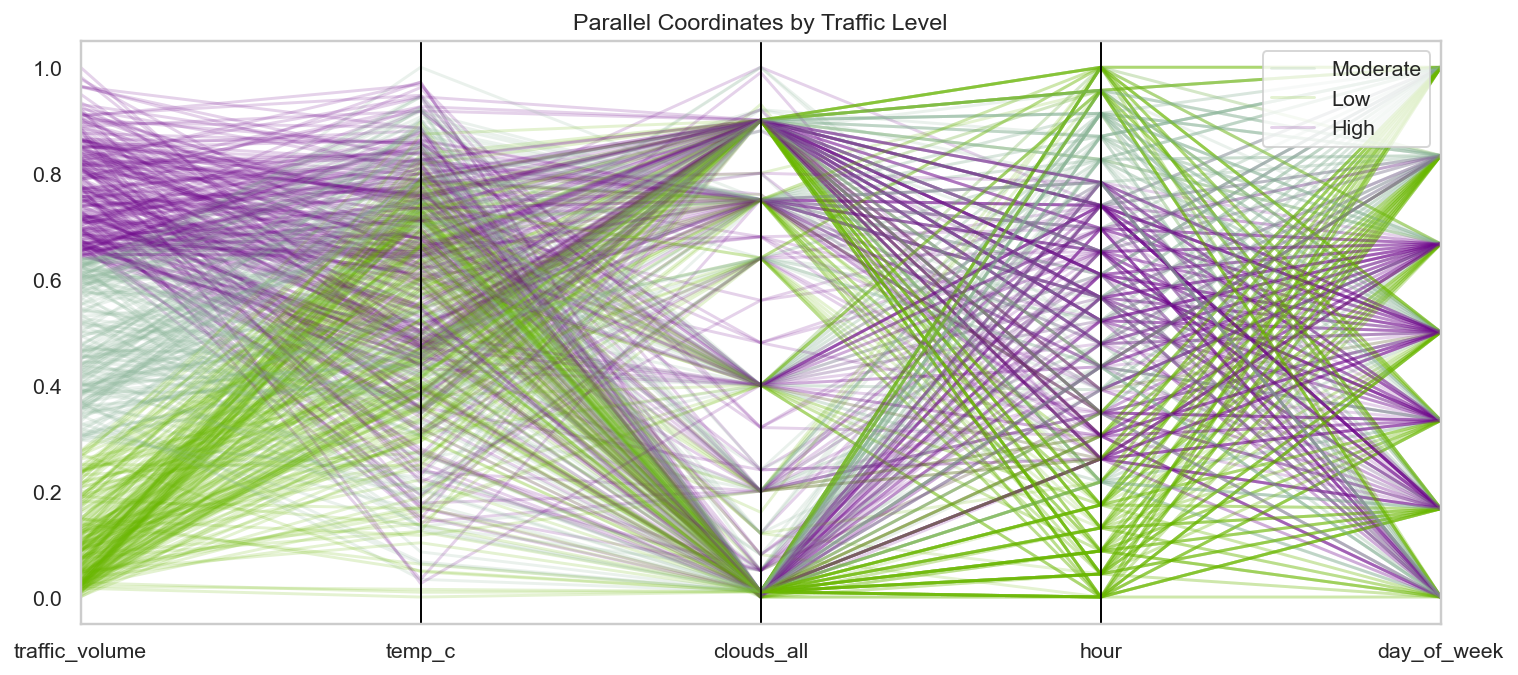

In [ ]:
parallel_sample = clean_df.sample(650, random_state=42)[['traffic_level', 'traffic_volume', 'temp_c', 'clouds_all', 'hour', 'day_of_week']].copy()
for col in ['traffic_volume', 'temp_c', 'clouds_all', 'hour', 'day_of_week']:
    parallel_sample[col] = (parallel_sample[col] - parallel_sample[col].min()) / (parallel_sample[col].max() - parallel_sample[col].min())
plt.figure(figsize=(11, 5))
parallel_coordinates(parallel_sample, 'traffic_level', alpha=0.18)
plt.title('Parallel Coordinates by Traffic Level')
plt.show()

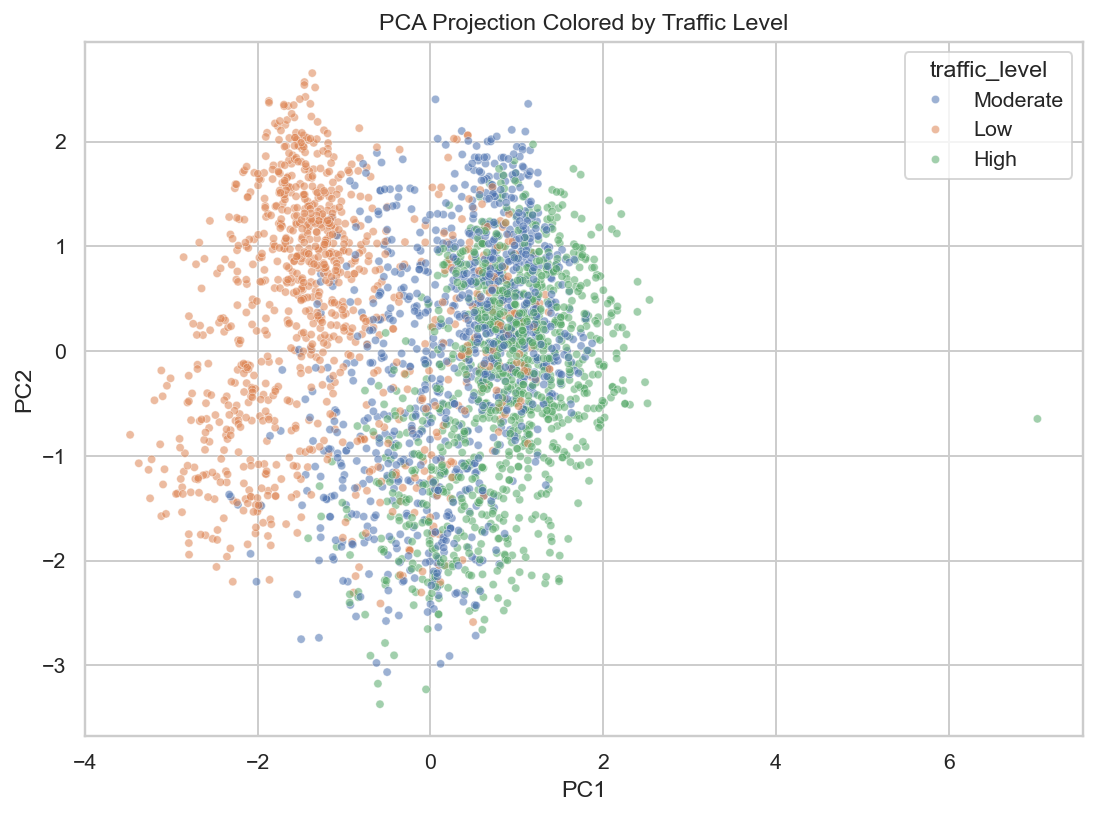

In [ ]:
pca_sample = clean_df.sample(3000, random_state=42)
features = ['traffic_volume', 'temp_c', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month']
coords = PCA(n_components=2, random_state=42).fit_transform(StandardScaler().fit_transform(pca_sample[features]))
pca_df = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1], 'traffic_level': pca_sample['traffic_level'].astype(str)})
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='traffic_level')
plt.title('PCA Projection Colored by Traffic Level')
plt.show()

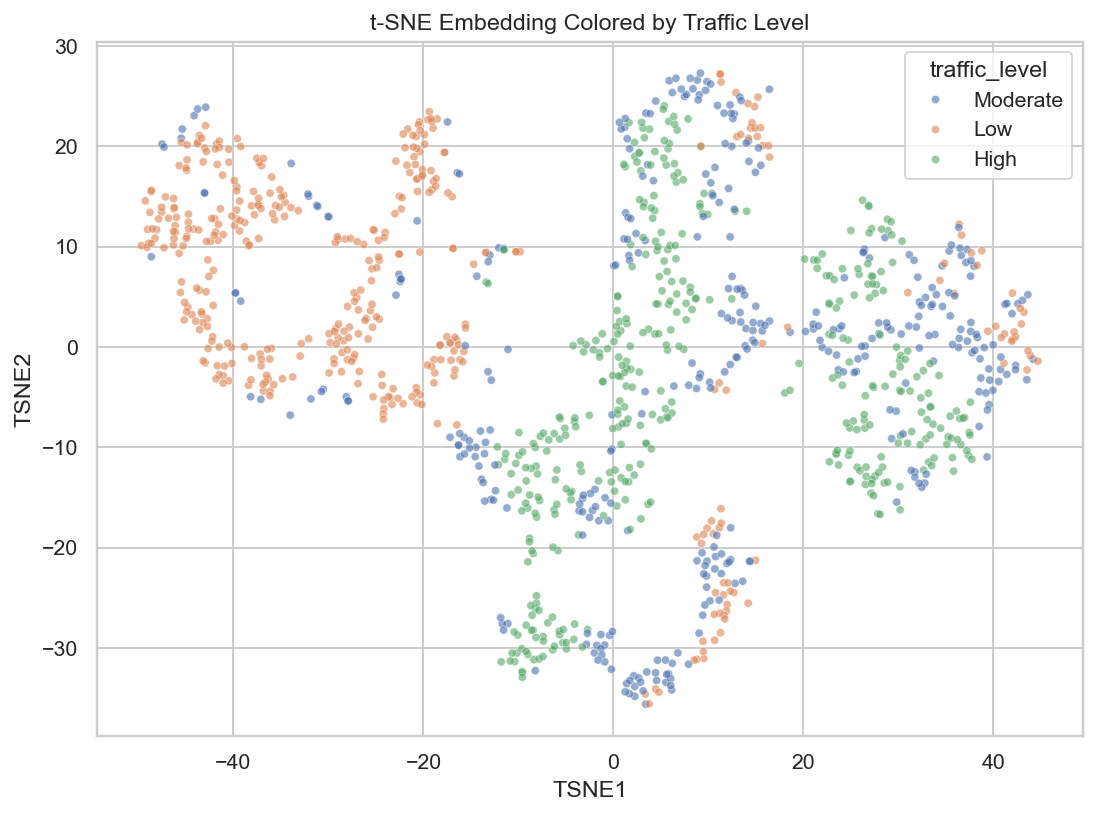

In [ ]:
tsne_sample = clean_df.sample(1200, random_state=42)
features = ['traffic_volume', 'temp_c', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month']
coords = TSNE(n_components=2, perplexity=35, random_state=42, init='pca', learning_rate='auto').fit_transform(StandardScaler().fit_transform(tsne_sample[features]))
tsne_df = pd.DataFrame({'TSNE1': coords[:, 0], 'TSNE2': coords[:, 1], 'traffic_level': tsne_sample['traffic_level'].astype(str)})
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='traffic_level')
plt.title('t-SNE Embedding Colored by Traffic Level')
plt.show()

## Target-Conditional Distributions

Class-wise histograms, boxplots, and violin plots.

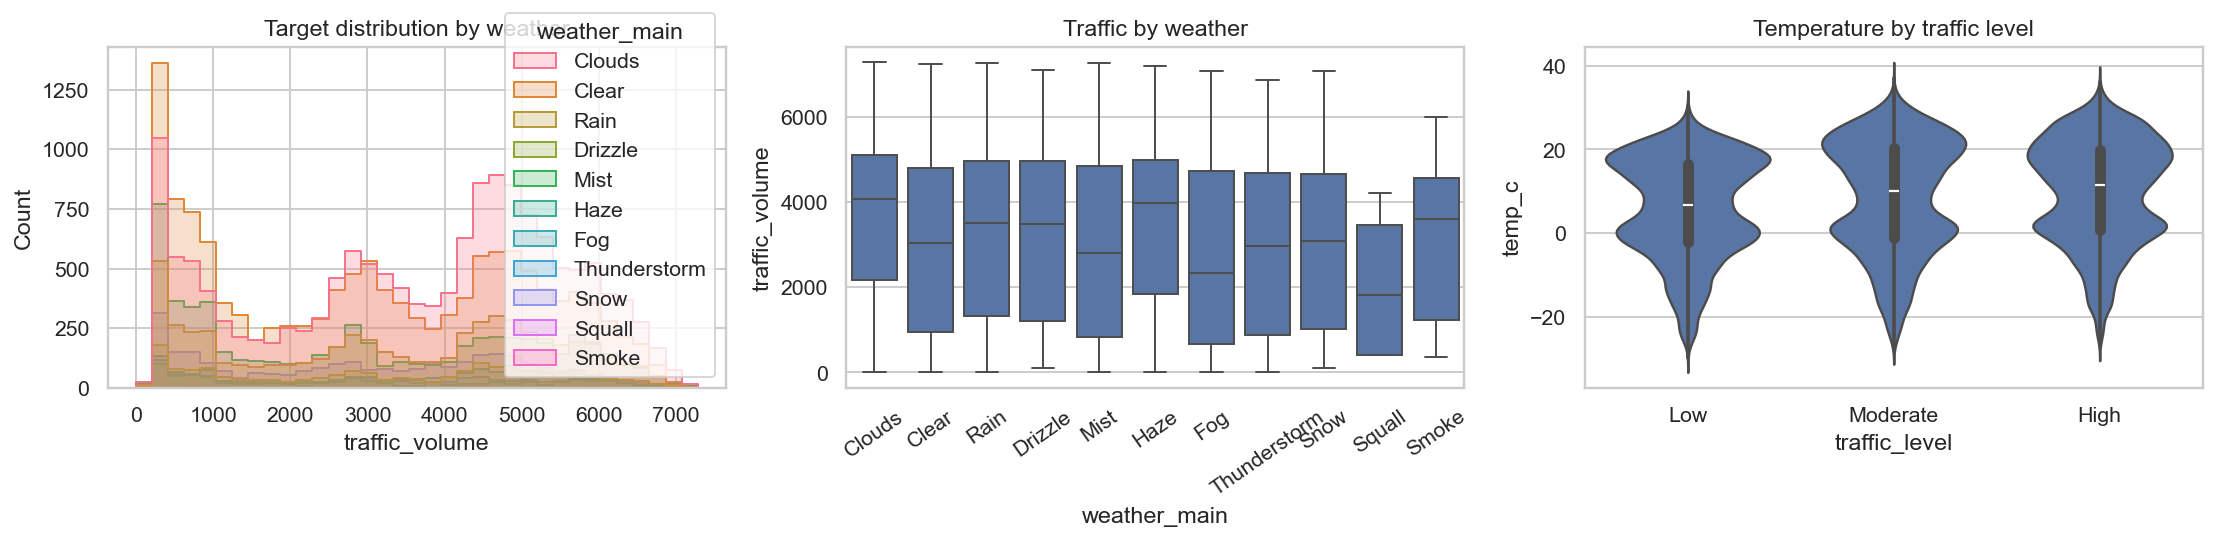

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=clean_df, x='traffic_volume', hue='weather_main', bins=35, element='step', ax=axes[0])
sns.boxplot(data=clean_df, x='weather_main', y='traffic_volume', ax=axes[1])
sns.violinplot(data=clean_df, x='traffic_level', y='temp_c', ax=axes[2])
plt.show()

## Train-Test Distribution Comparison

Chronological split and distribution drift check.

In [ ]:
split_summary

     split  rows               start                 end
     train 33735 2012-10-02 09:00:00 2017-05-17 21:00:00
validation  7229 2017-05-17 21:00:00 2018-01-25 19:00:00
      test  7230 2018-01-25 19:00:00 2018-09-30 23:00:00


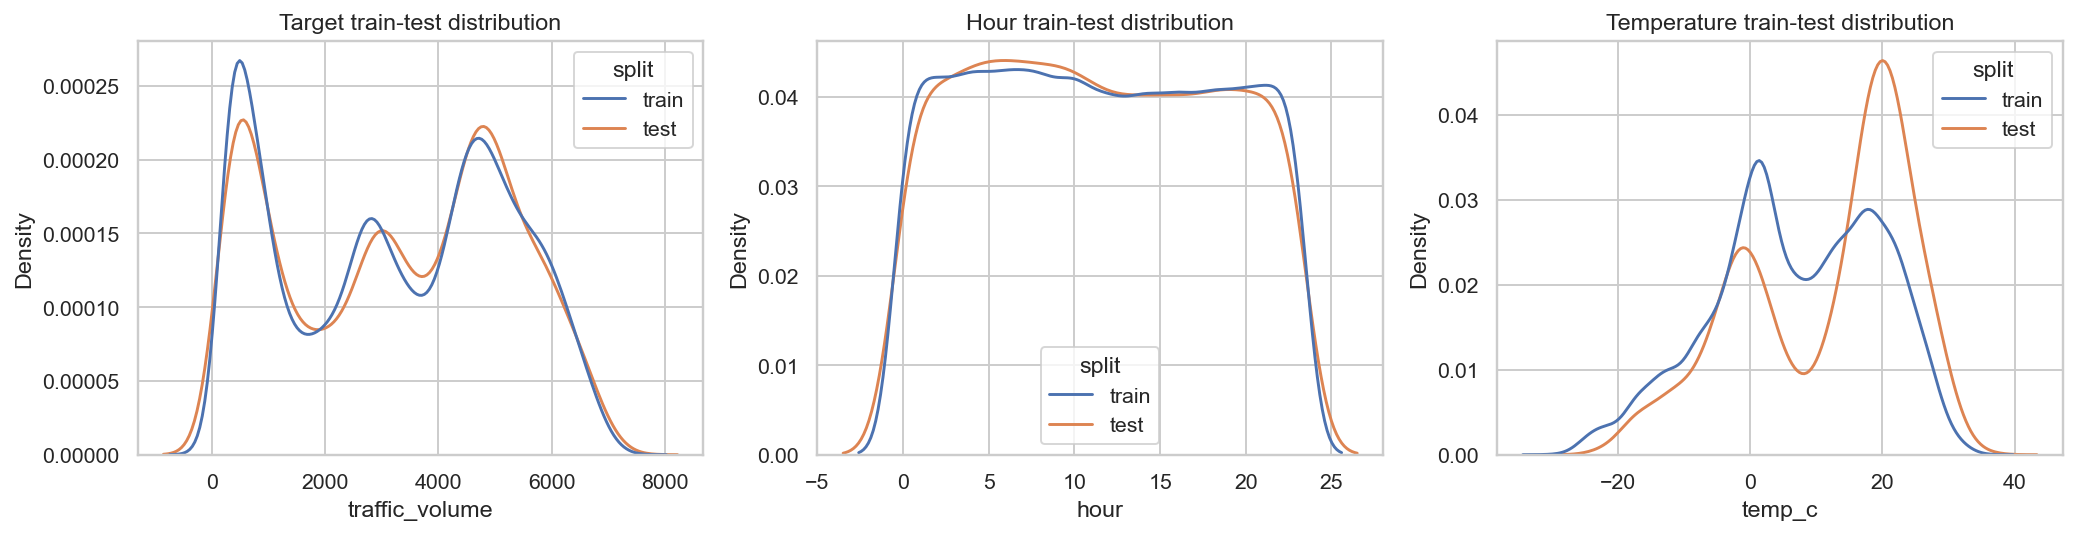

In [ ]:
drift_df = pd.concat([clean_df.iloc[:train_end].assign(split='train'), clean_df.iloc[val_end:].assign(split='test')])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.kdeplot(data=drift_df, x='traffic_volume', hue='split', common_norm=False, ax=axes[0])
sns.kdeplot(data=drift_df, x='hour', hue='split', common_norm=False, ax=axes[1])
sns.kdeplot(data=drift_df, x='temp_c', hue='split', common_norm=False, ax=axes[2])
plt.show()

## Time Trend

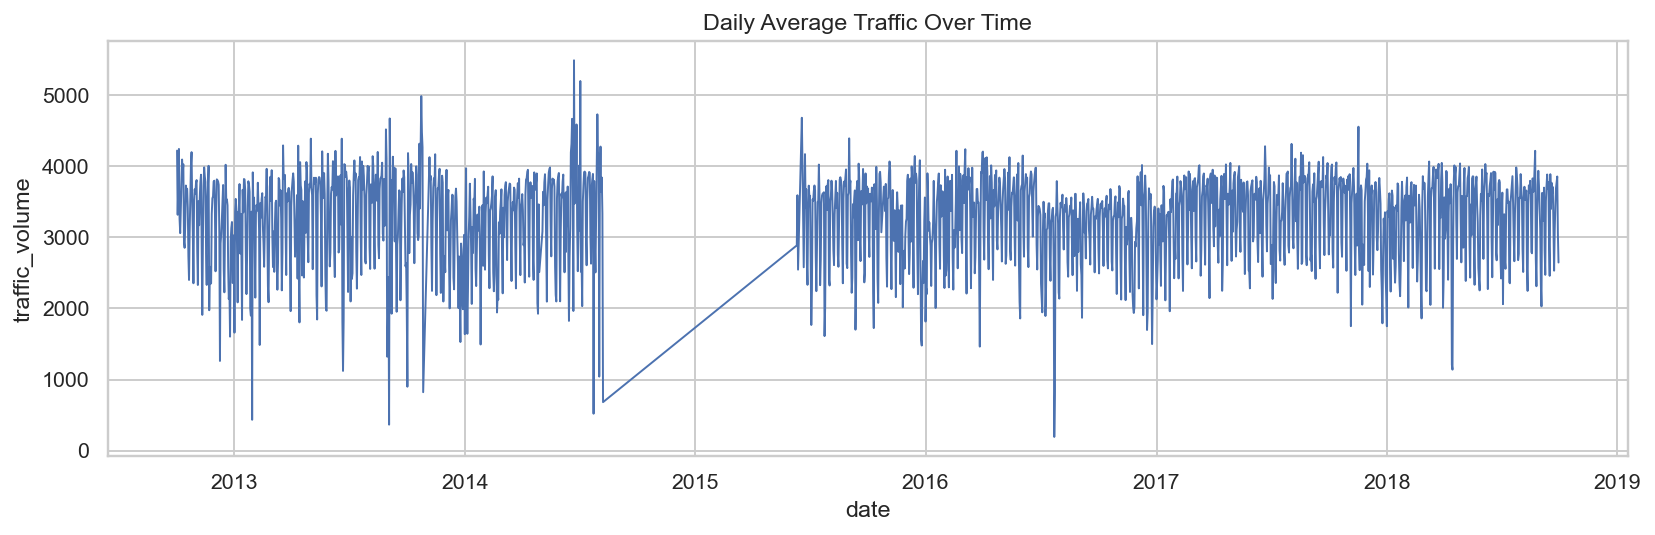

In [ ]:
daily = clean_df.groupby('date')['traffic_volume'].mean().reset_index()
plt.figure(figsize=(12, 4))
sns.lineplot(data=daily, x='date', y='traffic_volume', linewidth=1)
plt.title('Daily Average Traffic Over Time')
plt.show()